<a href="https://colab.research.google.com/github/mihhwiNick/DA_project/blob/DA/EDA-BenhTieuDuong/EDA-Benh_Dai-Thao-Duong.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**Phân tích khám phá về bệnh đái tháo đường**

##**1.Định nghĩa vấn đề**
+ **Mô tả**:
   + Bộ dữ liệu gồm 768 mẫu từ bệnh nhân đều là nữ giới, ít nhất 21 tuổi, và có nguồn gốc người da đỏ Pima, sống gần Phoenix, Arizona.
   + 8 đặc điểm được đo từ mỗi mẫu + 1 biến phân loại (có/không mắc tiểu đường)
+ **Dữ liệu vào**:
   + Số lần mang thai (lần)
   + Nồng độ glucose huyết tương sau 2 giờ trong xét nghiệm dung nạp glucose đường uống (mg/dL)
   + Huyết áp tâm trương (mm Hg)
   + Độ dày nếp gấp da cơ tam đầu (mm)
   + Nồng độ insulin huyết thanh sau 2 giờ (mu U/ml)
   + Chỉ số khối cơ thể BMI (kg/m²)
   + Hàm phả hệ tiểu đường ()
   + Tuổi (năm)
   + Biến phân loại (nhị phân)
+ **Dữ liệu ra**:
   + Dự đoán bệnh nhân có tiểu đường không (Biến phân loại 0 hoặc 1)
+ **Mục tiêu**:
   + Phân tích bộ dữ liệu bệnh đái tháo đường nhằm hiểu rõ các yếu tố liên quan đến nguy cơ mắc bệnh.
   + Vận dụng kiến thức về dinh dưỡng để đánh giá ảnh hưởng của chế độ ăn uống đến tình trạng bệnh.


## **2.Chuẩn bị vấn đề**

### **2.1.Khai báo thư viện**

In [ ]:
# Load libraries
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn.model_selection as mod
import sklearn.neighbors as nei
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import LeaveOneOut
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, roc_auc_score, classification_report, precision_recall_curve, average_precision_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import cross_val_score
from sklearn.feature_selection import RFECV
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
import operator
%matplotlib inline

### **2.2.Nạp dữ liệu**

In [ ]:
#load data
pima = pd.read_csv('https://raw.githubusercontent.com/mihhwiNick/DA_project/refs/heads/main/pima-indians-diabetes.data.csv')

### **2.3.Kiểm tra và làm sạch dữ liệu**

#### **2.3.1. Kiểm tra tính toàn vẹn của dữ liệu**
+ Dữ liệu có bị trùng lặp không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị Null không? Hiển thị dòng bị vi phạm.
+ Dữ liệu có tồn tại giá trị NaN không? Hiển thị dòng bị vi phạm.

In [ ]:
# Loại bỏ cột Outcome khi kiểm tra giá trị 0
cols_to_check = pima.columns.drop("Outcome")
rows_with_zero = (pima[cols_to_check] == 0).any(axis=1)
count_rows_with_zero = rows_with_zero.sum()

has_null = pima.isnull().sum().any()
has_nan  = pima.isna().sum().any()
n_duplicated = pima.duplicated().sum()

print('Tính toàn vẹn dữ liệu:')
print(f'+ Có giá trị Null: {has_null}')
if has_null:
    display(pima[pima.isnull().any(axis=1)])

print(f'+ Có giá trị NaN: {has_nan}')
if has_nan:
    display(pima[pima.isna().any(axis=1)])

print(f'+ Số dòng trùng: {n_duplicated}')
if n_duplicated > 0:
    s_query1 = "`Pregnancies`==6 and `Glucose`==148 and `Outcome`==1"
    s_query2 = "`Pregnancies`==1 and `Glucose`==85 and `Outcome`==0"
    display(pima.query(s_query1))
    display(pima.query(s_query2))
    display(pima[pima.duplicated()])

zero_counts_all = (pima == 0).sum()


cols_check = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Đếm số dòng có giá trị = 0 ở các cột này
zero_counts = (pima[cols_check] == 0).sum()

print("Số lượng dòng có giá trị = 0 ở từng cột được chọn:")
print(zero_counts)

Tính toàn vẹn dữ liệu:
+ Có giá trị Null: False
+ Có giá trị NaN: False
+ Số dòng trùng: 0
Số lượng dòng có giá trị = 0 ở từng cột được chọn:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


**Nhận xét**:
+ Không có dữ liệu nào trùng nhau
+ Dữ liệu không có giá trị rỗng (NaN, Null).
+ Tuy nhiên, khi kiểm tra chi tiết, phát hiện một số cột có giá trị = 0 không hợp lý về mặt y học, được coi là dữ liệu thiếu:
  + Glucose: không thể bằng 0 vì cơ thể luôn có đường huyết lưu hành.

  + BloodPressure: không thể bằng 0, vì huyết áp 0 chỉ xảy ra khi đã tử vong.

  + SkinThickness: không thể bằng 0, lớp mỡ dưới da luôn có độ dày nhất định.

  + Insulin: không thể bằng 0, vì tuyến tụy luôn tiết insulin nền.

  + BMI: không thể bằng 0, vì chỉ số khối cơ thể = 0 nghĩa là cân nặng = 0, điều này không thực tế.

## **3.Phân tích khám phá dữ liệu**

### **3.1.Phân tích đơn biến (Univariable Analysis)**

#### **3.1.1. Hiển thị một số thông tin về dữ liệu**
+ Số dòng, số cột của dữ liệu
+ Kiểu dữ liệu của từng cột
+ 5 dòng đầu và 5 dòng cuối của bảng dữ liệu
+ Thông tin chung về dữ liệu

In [ ]:
# Get shape
print(f'+ Shape: {pima.shape}')

# Get types
print(f'\n+ Data Types:\n{pima.dtypes}')

# Check the first 5 rows (head)
print('\n+ First 5 rows:')
display(pima.head(5))

# Check the last 5 rows (tail)
print('\n+ Last 5 rows:')
display(pima.tail(5))

# info
print('\n + Basic Information: ')
pima.info()

+ Shape: (768, 9)

+ Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

+ First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,30.5,33.6,0.627,50,1
1,1,85,66,29,30.5,26.6,0.351,31,0
2,8,183,64,23,30.5,23.3,0.672,32,1
3,1,89,66,23,94.0,28.1,0.167,21,0
4,0,137,40,35,168.0,43.1,2.288,33,1



+ Last 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180.0,32.9,0.171,63,0
764,2,122,70,27,30.5,36.8,0.340,27,0
765,5,121,72,23,112.0,26.2,0.245,30,0
766,1,126,60,23,30.5,30.1,0.349,47,1
767,1,93,70,31,30.5,30.4,0.315,23,0



 + Basic Information: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(3), int64(6)
memory usage: 54.1 KB


**Nhận xét**:
+ Dữ liệu có 8 tính chất để phân lớp: Pregnancies, Glucose, BloodPressure, SkinThickness, Insulin, BMI, DiabetesPedigreeFunction, Age
+ Các giá trị đều là số học, thuộc kiểu int64 và float64
+ Tổng số dòng dữ liệu là 768 dòng
+ Dữ liệu phân lớp nằm ở cột Outcome, gồm 2 giá trị: 0 (không mắc bệnh) và 1 (mắc bệnh)


#### **3.1.2. Các tính chất thống kê trên dữ liệu số**
+ Count, Mean, Standard Deviation, Minimum Value
+ 25th Percentile, 50th Percentile (Median), 75th Percentile, Maximum Value

In [ ]:
description = pima.drop(columns=["Outcome"]).describe().T
display(description)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.0,3.845052,3.369578,0.000,1.00000,3.0000,6.00000,17.00
Glucose,768.0,121.656250,30.438286,44.000,99.75000,117.0000,140.25000,199.00
BloodPressure,768.0,72.386719,12.096642,24.000,64.00000,72.0000,80.00000,122.00
SkinThickness,768.0,27.334635,9.229014,7.000,23.00000,23.0000,32.00000,99.00
Insulin,768.0,94.652344,105.547598,14.000,30.50000,31.2500,127.25000,846.00
BMI,768.0,32.450911,6.875366,18.200,27.50000,32.0000,36.60000,67.10
DiabetesPedigreeFunction,768.0,0.471876,0.331329,0.078,0.24375,0.3725,0.62625,2.42
Age,768.0,33.240885,11.760232,21.000,24.00000,29.0000,41.00000,81.00


**Nhận xét**:
+ **Pregnancies:** Trung bình 3.84, dao động 0–17 → hợp lý, vì có thể có phụ nữ chưa mang thai.
+ **Glucose:** Giá trị trung bình là 120.89, với mức cao nhất là 199. Phân phối cho thấy có sự đa dạng về mức đường huyết trong nhóm nghiên cứu, phản ánh rõ nguy cơ tiểu đường.
+ **BloodPressure:** Huyết áp trung bình là 69.1, nằm trong ngưỡng bình thường. Giá trị cao nhất là 122, cho thấy có một số trường hợp tăng huyết áp.
+ **SkinThickness:** Độ dày lớp mỡ dưới da trung bình là 20.5, với giá trị cao nhất là 99. Phân phối khá rộng, thể hiện sự khác biệt về thể trạng giữa các cá nhân.
+ **Insulin:** Mức insulin trung bình là 79.8, nhưng giá trị cao nhất lên tới 846, cho thấy có một số trường hợp rối loạn chuyển hóa rõ rệt.
+ **BMI:** Chỉ số khối cơ thể trung bình là 31.99, nằm trong ngưỡng thừa cân. Một số cá nhân có BMI rất cao (tối đa 67.1), cho thấy nguy cơ béo phì.
+ **DiabetesPedigreeFunction:** Hệ số di truyền trung bình là 0.47, dao động từ 0.078 đến 2.42. Phân phối này phản ánh mức độ ảnh hưởng của yếu tố di truyền đến nguy cơ mắc bệnh.
+ **Age:** Tuổi trung bình là 33.24, dao động từ 21 đến 81. Phân phối tuổi phù hợp với nhóm dân số trưởng thành, có nguy cơ tiểu đường tăng theo tuổi.


#### **3.1.3. Tần số xuất hiện trên dữ liệu phân loại**

In [ ]:
pima["Outcome"].value_counts()

,count
Outcome,
0,500
1,268


**Nhận xét**:
+ Dữ liệu không cân bằng: lớp 0 chiếm khoảng 65%, lớp 1 chiếm khoảng 35%, điều này có thể làm mô hình thiên lệch về lớp đa số.
+ **Giải pháp**: có thể áp dụng oversampling (SMOTE) để tăng số mẫu lớp 1, hoặc undersampling để giảm số mẫu lớp 0

#### **3.1.4.Biểu đồ violin cho từng biến**

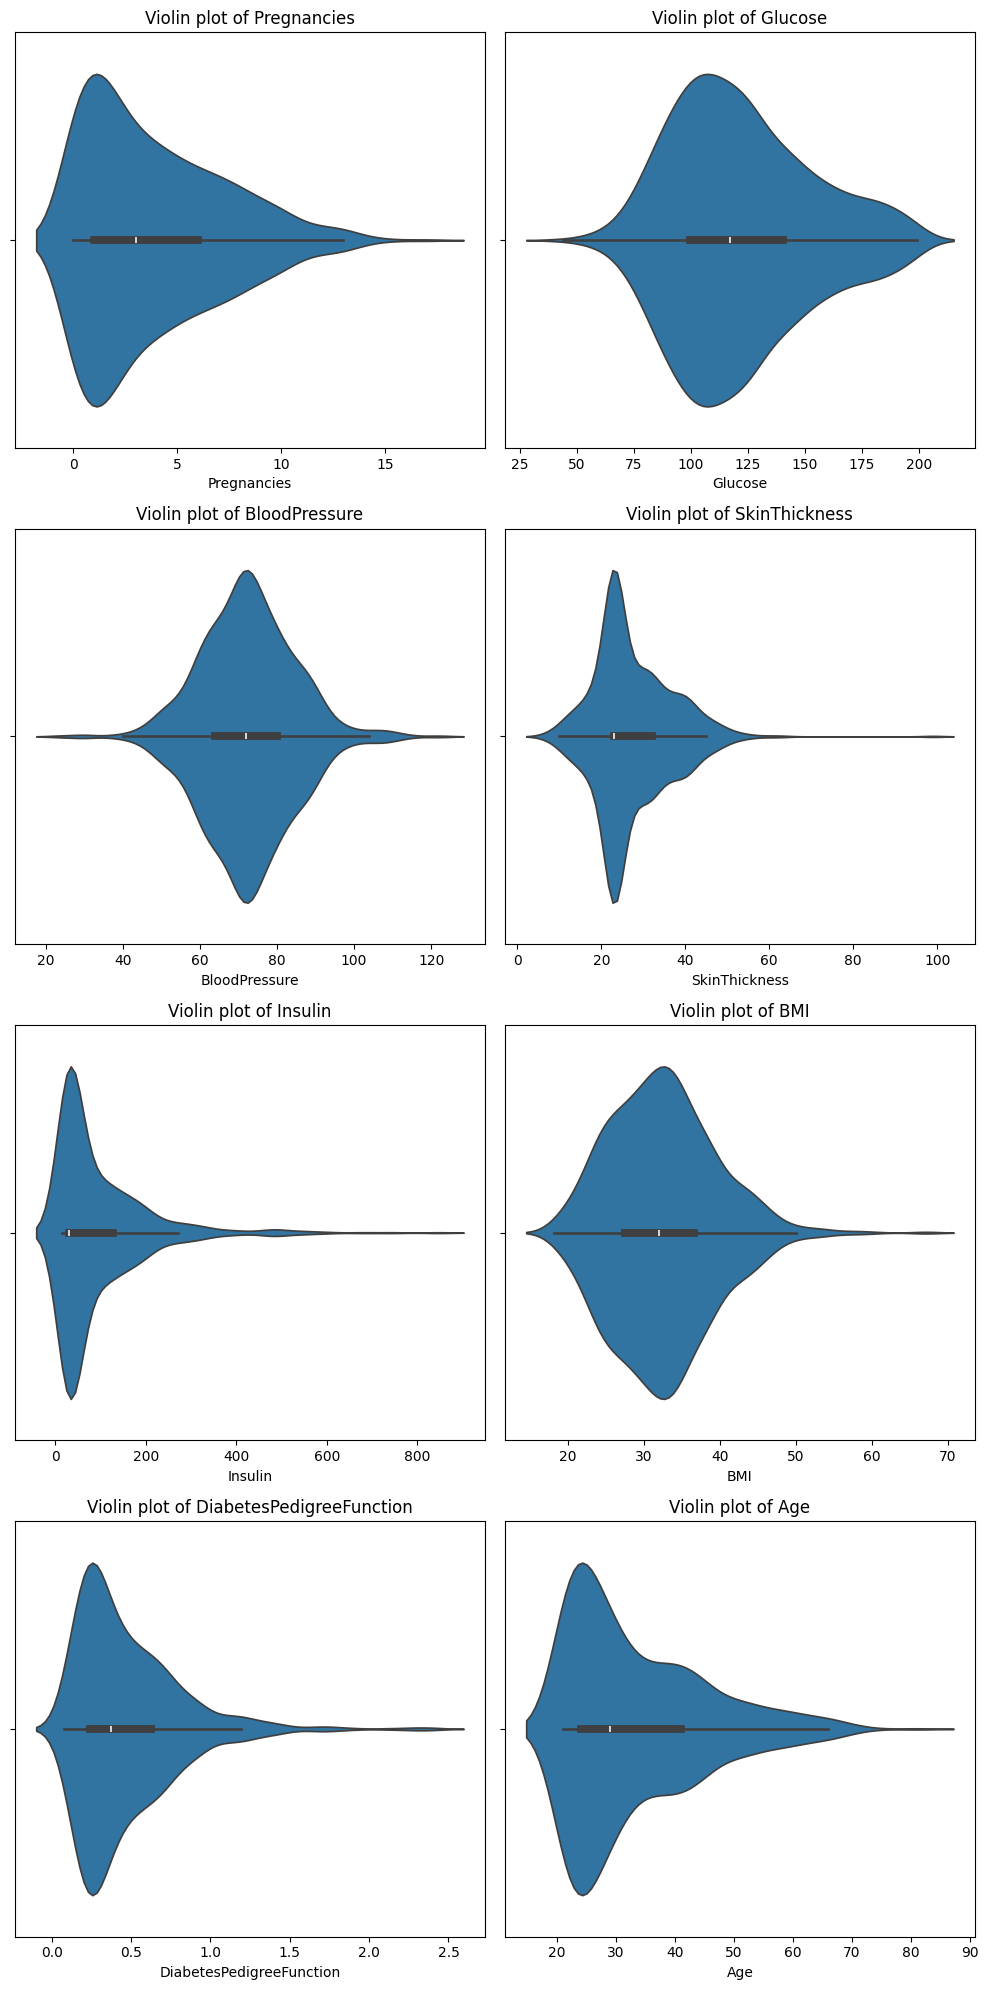

In [ ]:
num_columns = len(pima.columns.drop('Outcome'))
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(10, 5*num_rows))
for i, column in enumerate(pima.columns.drop('Outcome')):
    plt.subplot(num_rows, 2, i+1)
    sns.violinplot(x=pima[column])
    plt.title(f'Violin plot of {column}')

plt.tight_layout()
plt.show()

#### **3.1.5.Biểu đồ ước lượng mật độ kernel (KDE) cho từng biến**

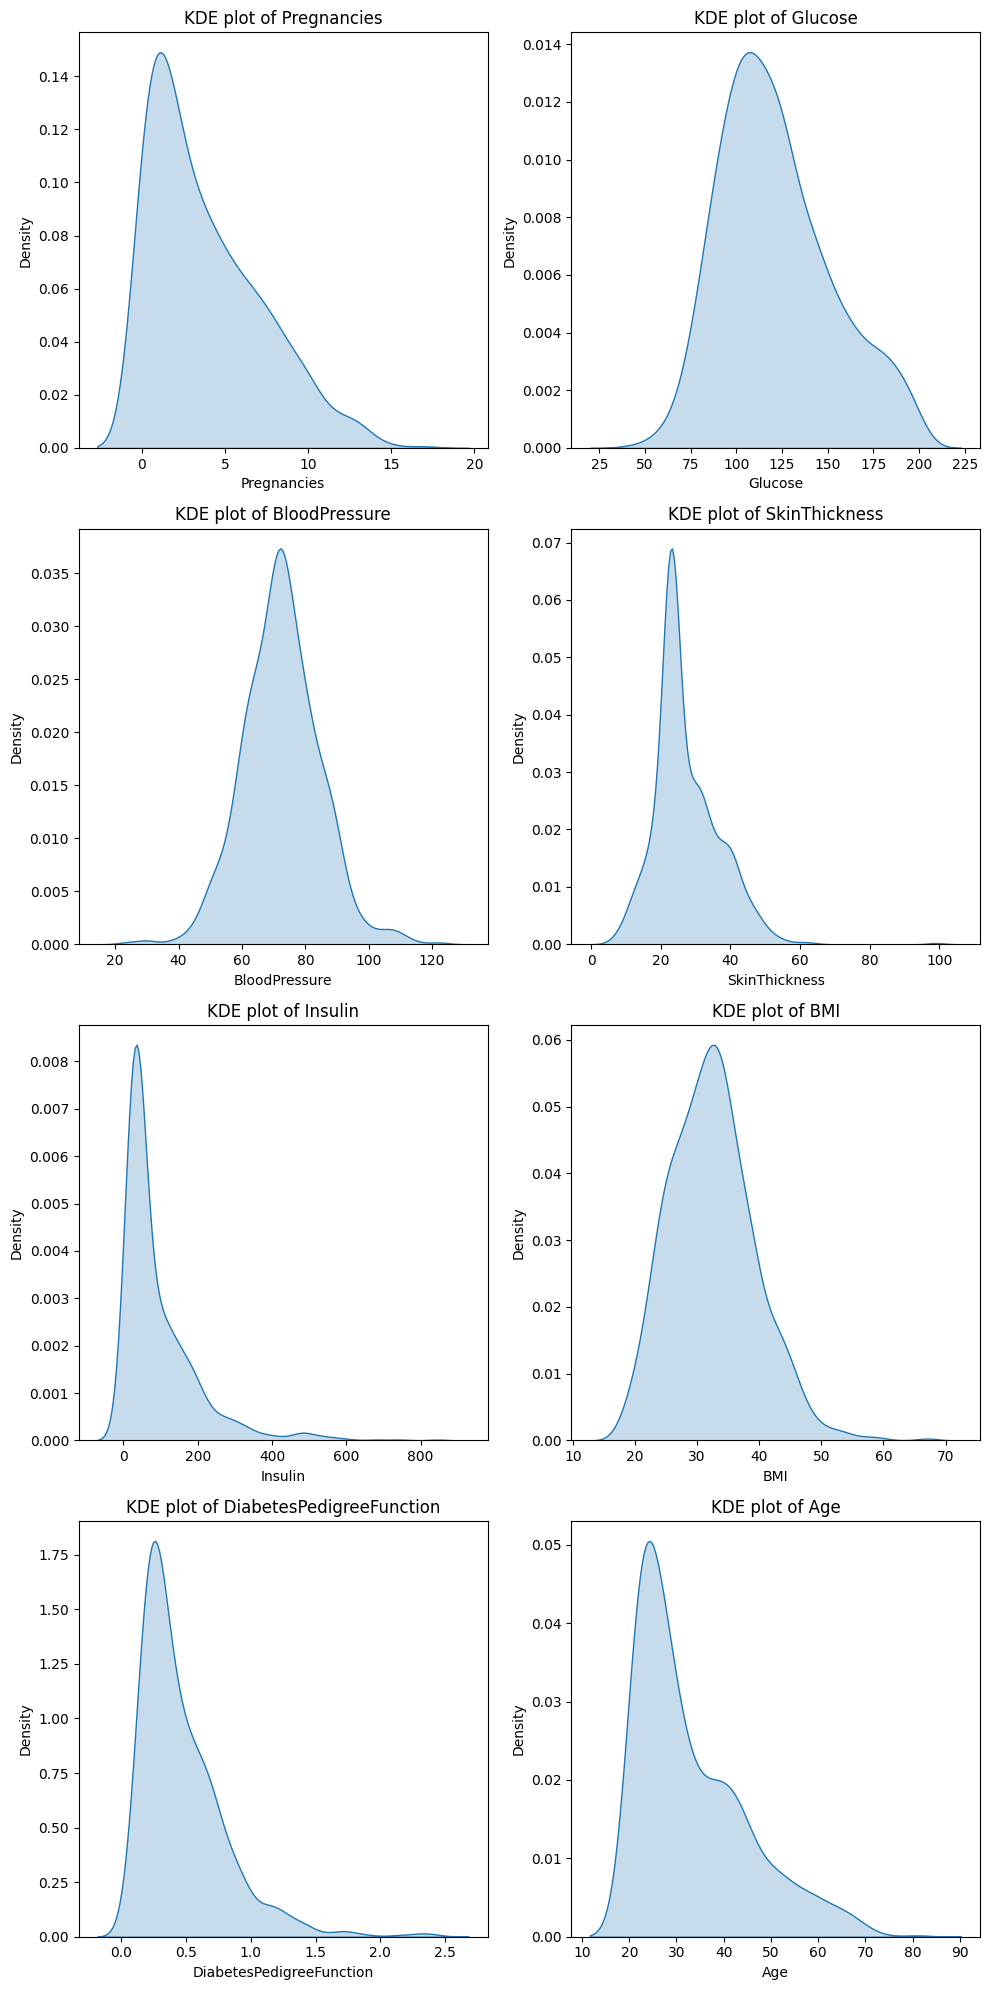

In [ ]:
num_columns = len(pima.columns.drop('Outcome'))
num_rows = (num_columns + 1) // 2

plt.figure(figsize=(10, 5*num_rows))

# Select only numeric columns for KDE plot
numeric_cols = pima.select_dtypes(include=np.number).columns.drop('Outcome', errors='ignore')

for i, column in enumerate(numeric_cols):
    plt.subplot(num_rows, 2, i+1)
    sns.kdeplot(data=pima[column], fill=True)
    plt.title(f'KDE plot of {column}')

plt.tight_layout()
plt.show()

### **3.2.Phân tích đa biến (Multivariable Analysis)**

#### **3.2.1. So sánh trung bình các đặc điểm theo nhóm Outcome**

In [ ]:
# Tính giá trị trung bình của các biến theo nhóm Outcome
pima.groupby('Outcome').mean()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
Outcome,,,,,,,,
0,3.298000,110.682000,70.920000,26.058000,83.188000,30.880200,0.429734,31.190000
1,4.865672,142.130597,75.123134,29.716418,116.041045,35.381343,0.550500,37.067164


**Nhận xét**: Kết quả cho thấy nhóm phụ nữ mắc tiểu đường có xu hướng sở hữu các đặc điểm sinh lý với giá trị trung bình cao hơn so với nhóm không mắc bệnh.

In [ ]:
# Lấy giá trị trung bình của từng biến trong dataset
pima.mean()

,0
Pregnancies,3.845052
Glucose,121.656250
BloodPressure,72.386719
SkinThickness,27.334635
Insulin,94.652344
BMI,32.450911
DiabetesPedigreeFunction,0.471876
Age,33.240885
Outcome,0.348958


**Nhận xét**:
- **Pregnancies:** Trung bình 3.85 lần mang thai, phản ánh nhóm phụ nữ đã từng sinh nở, phù hợp với đối tượng nghiên cứu.
- **Glucose:** Mức đường huyết trung bình là 121.66 mg/dL, tiệm cận ngưỡng chẩn đoán tiểu đường (126 mg/dL), cho thấy nguy cơ bệnh trong tập dữ liệu là đáng chú ý.
- **BloodPressure:** Huyết áp trung bình là 72.39 mmHg, nằm trong ngưỡng bình thường. Đây là mức ổn định, tuy nhiên vẫn cần kiểm tra sự khác biệt giữa các nhóm bệnh.
- **SkinThickness:** Độ dày lớp mỡ dưới da trung bình là 27.33 mm, cho thấy thể trạng tương đối ổn định trong nhóm nghiên cứu. Đây là một đặc điểm có thể liên quan đến tình trạng béo phì và nguy cơ rối loạn chuyển hóa.
- **Insulin:** Mức insulin trung bình là 94.65 µU/mL, cho thấy chức năng chuyển hóa ở mức phổ thông. Tuy nhiên, đây vẫn là biến cần theo dõi vì có thể liên quan đến tình trạng kháng insulin.
- **BMI:** Chỉ số khối cơ thể trung bình là 32.45, vượt ngưỡng 30 – cho thấy tình trạng thừa cân hoặc béo phì là phổ biến trong tập dữ liệu.
- **DiabetesPedigreeFunction:** Hệ số di truyền trung bình là 0.47, cho thấy mức độ ảnh hưởng di truyền ở mức vừa phải.
- **Age:** Tuổi trung bình là 33.24, phù hợp với nhóm dân số trưởng thành, độ tuổi có nguy cơ tiểu đường bắt đầu tăng.
- **Outcome:** Tỷ lệ trung bình là 0.34, tức khoảng 35% người trong tập dữ liệu có kết quả dương tính với tiểu đường — đủ để phân tích sự khác biệt giữa hai nhóm.


#### **3.2.2. Phân tích tương quan**

In [ ]:
pima.corr()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.032568,-0.055697,0.021546,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.172143,0.357573,0.231400,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.147809,-0.028721,0.281132,-0.002378,0.324915,0.165723
SkinThickness,0.032568,0.172143,0.147809,1.000000,0.238188,0.546951,0.142977,0.054514,0.189065
Insulin,-0.055697,0.357573,-0.028721,0.238188,1.000000,0.189022,0.178029,-0.015413,0.148457
BMI,0.021546,0.231400,0.281132,0.546951,0.189022,1.000000,0.153506,0.025744,0.312249
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.142977,0.178029,0.153506,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.054514,-0.015413,0.025744,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.189065,0.148457,0.312249,0.173844,0.238356,1.000000


**Nhận xét chính: Mối tương quan với biến Outcome (kết quả bị tiểu đường)**
- Glucose (Nồng độ đường trong máu): Có hệ số tương quan là 0.492. Đây là mối tương quan dương mạnh nhất với Outcome. Điều này có nghĩa là nồng độ glucose càng cao thì khả năng bị tiểu đường càng cao. Đây là yếu tố dự báo quan trọng nhất.

- BMI (Chỉ số khối cơ thể): Hệ số tương quan là 0.312. Đây là mối tương quan dương ở mức trung bình. Người có chỉ số BMI cao hơn có xu hướng có nguy cơ bị tiểu đường cao hơn.

- Age (Tuổi): Hệ số tương quan là 0.238. Tương quan dương ở mức vừa phải. Tuổi tác càng cao thì nguy cơ mắc bệnh tiểu đường càng tăng.

- Pregnancies (Số lần mang thai): Hệ số tương quan là 0.221. Tương quan dương ở mức vừa phải. Số lần mang thai nhiều hơn có liên quan đến nguy cơ tiểu đường cao hơn.

- Các biến còn lại như SkinThickness (Độ dày nếp gấp da), Insulin, DiabetesPedigreeFunction (Hàm phả hệ tiểu đường), và BloodPressure (Huyết áp) đều có tương quan dương yếu với Outcome.

##### **3.2.2.1. So sánh trung bình Glucose theo nhóm Outcome**

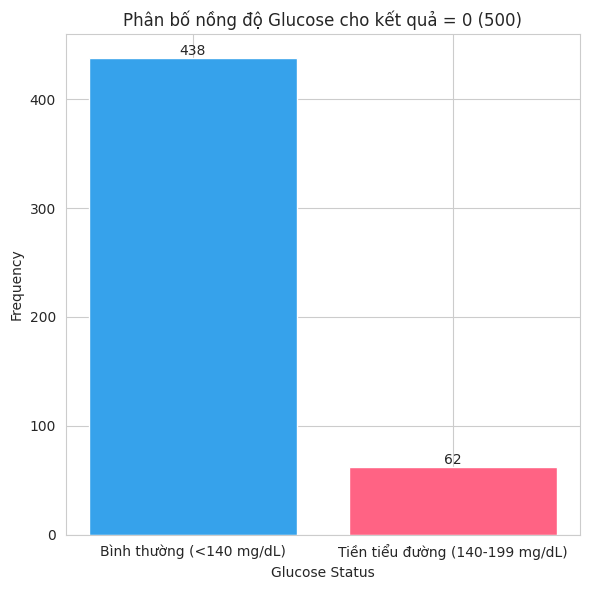

Thống kê phân bố Glucose cho Outcome = 0:
                 Glucose Status  Frequency  Percentage (%)
       Bình thường (<140 mg/dL)        438            87.6
Tiền tiểu đường (140-199 mg/dL)         62            12.4


In [ ]:
#Biểu đồ cột nồng độ Glucose cho kết quả = 0
# Hàm phân loại tình trạng glucose
def classify_glucose(glucose_level):
    if glucose_level < 140:
        return "Bình thường (<140 mg/dL)"
    elif 140 <= glucose_level <= 199:
        return "Tiền tiểu đường (140-199 mg/dL)"
    elif glucose_level >= 200:
        return "Tiểu đường type 2 (≥200 mg/dL)"
    else:
        return "Không xác định"

# Lọc dữ liệu cho Outcome = 0
glucose_outcome_0 = pima[pima['Outcome'] == 0]['Glucose'].dropna()

# Áp dụng phân loại
glucose_status = glucose_outcome_0.apply(classify_glucose)

# Đếm số lượng theo từng trạng thái
status_counts = glucose_status.value_counts()

# Tính tổng số người có Outcome = 0
total_outcome_0 = len(pima[pima['Outcome'] == 0])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Glucose Status': status_counts.index,
    'Frequency': status_counts.values,
    'Percentage (%)': (status_counts.values / total_outcome_0 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(6, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FF6384', '#FFCD56'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố nồng độ Glucose cho kết quả = 0 (500)')
plt.xlabel('Glucose Status')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố Glucose cho Outcome = 0:")
print(status_df.to_string(index=False))

**Nhận xét**
- Phân bố dữ liệu: Phần lớn (87.6% với 438 người) có mức glucose bình thường (< 140 mg/dL), trong khi chỉ một phần nhỏ (12.4% với 62 người) rơi vào mức tiền tiểu đường (140-199 mg/dL). Điều này cho thấy xu hướng chung là glucose ở mức bình thường trong nhóm không mắc bệnh.

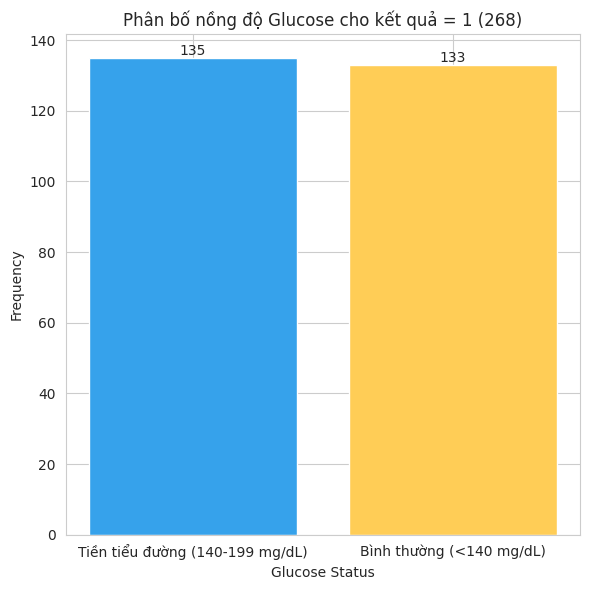

Thống kê phân bố Glucose cho Outcome = 1:
                 Glucose Status  Frequency  Percentage (%)
Tiền tiểu đường (140-199 mg/dL)        135           50.37
       Bình thường (<140 mg/dL)        133           49.63


In [ ]:
#Biểu đồ cột nồng độ Glucose cho kết quả = 1
# Hàm phân loại tình trạng glucose
def classify_glucose(glucose_level):
    if glucose_level < 140:
        return "Bình thường (<140 mg/dL)"
    elif 140 <= glucose_level <= 199:
        return "Tiền tiểu đường (140-199 mg/dL)"
    elif glucose_level >= 200:
        return "Tiểu đường type 2 (≥200 mg/dL)"
    else:
        return "Không xác định"

# Lọc dữ liệu cho Outcome = 1
glucose_outcome_1 = pima[pima['Outcome'] == 1]['Glucose'].dropna()

# Áp dụng phân loại
glucose_status = glucose_outcome_1.apply(classify_glucose)

# Đếm số lượng theo từng trạng thái
status_counts = glucose_status.value_counts()

# Tính tổng số người có Outcome = 1
total_outcome_1 = len(pima[pima['Outcome'] == 1])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Glucose Status': status_counts.index,
    'Frequency': status_counts.values,
    'Percentage (%)': (status_counts.values / total_outcome_1 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(6, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384'])  # Gán màu cố định

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố nồng độ Glucose cho kết quả = 1 (268)')
plt.xlabel('Glucose Status')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê
print("Thống kê phân bố Glucose cho Outcome = 1:")
print(status_df.to_string(index=False))

**Nhận xét**
- Hai nhóm có số lượng và phần trăm rất gần nhau (135 người, 50.37% cho "Tiền tiểu đường" và 133 người, 49.63% cho "Bình thường"), cho thấy sự phân bố khá cân bằng giữa các mức glucose trong nhóm mắc đái tháo đường. Điều này có thể ngụ ý rằng một số người mắc bệnh có mức glucose bình thường, có thể do chẩn đoán dựa trên các yếu tố khác

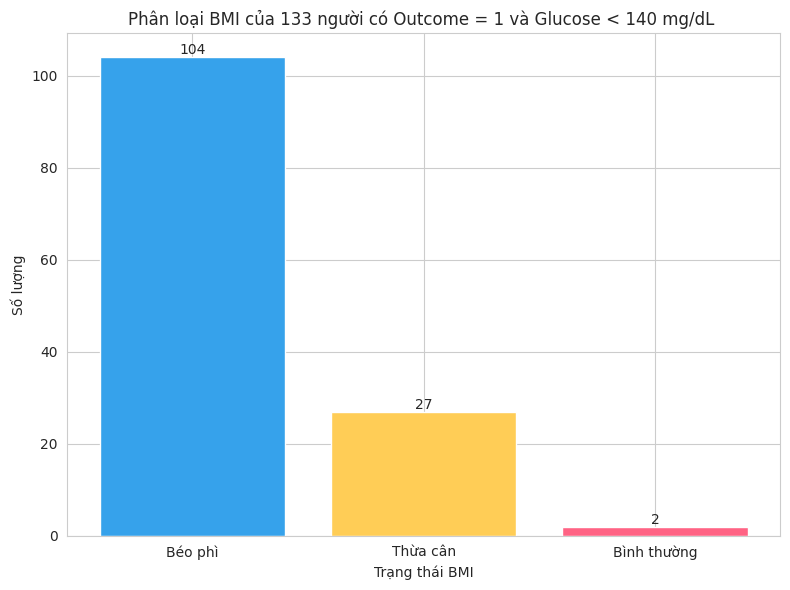

In [ ]:
# Lọc dữ liệu cho Outcome = 1 và Glucose < 140 mg/dL
diabetic_low_glucose = pima[(pima['Outcome'] == 1) & (pima['Glucose'] < 140)].dropna()

# Tạo mảng để lưu trạng thái BMI
BMI_status = [None] * len(diabetic_low_glucose)

# Phân loại trạng thái BMI
for i in range(len(diabetic_low_glucose)):
    if diabetic_low_glucose['BMI'].iloc[i] == 0.0:
        BMI_status[i] = "Không có dữ liệu"
    elif diabetic_low_glucose['BMI'].iloc[i] < 18.5:
        BMI_status[i] = "Thiếu cân"
    elif diabetic_low_glucose['BMI'].iloc[i] < 25:
        BMI_status[i] = "Bình thường"
    elif diabetic_low_glucose['BMI'].iloc[i] < 30:
        BMI_status[i] = "Thừa cân"
    elif diabetic_low_glucose['BMI'].iloc[i] >= 30:
        BMI_status[i] = "Béo phì"
    else:
        BMI_status[i] = diabetic_low_glucose['BMI'].iloc[i]

# Thêm cột BMI_status vào DataFrame con
diabetic_low_glucose = diabetic_low_glucose.assign(BMI_status=BMI_status)

# Đếm số lượng theo từng trạng thái BMI
bmi_counts = diabetic_low_glucose['BMI_status'].value_counts()

# Vẽ biểu đồ cột cho phân loại BMI
plt.figure(figsize=(8, 6))
bars = plt.bar(bmi_counts.index, bmi_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700', '#CCCCCC'])
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{int(height)}', ha='center', va='bottom')
plt.title('Phân loại BMI của 133 người có Outcome = 1 và Glucose < 140 mg/dL ')
plt.xlabel('Trạng thái BMI')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



**Nhận xét**
- BMI của 133 người có Outcome = 1 và Glucose < 140 mg/dL thì có 102 người bị béo phì và 27 người thừa cân

In [ ]:
#2 người có chỉ số BMI bình thường Outcome = 1 và Glucose < 140 mg/dL
diabetic_low_glucose_normal_bmi = pima[(pima['Outcome'] == 1) &
                                      (pima['Glucose'] < 140) &
                                      (pima['BMI'] >= 18.5) &
                                      (pima['BMI'] < 25)].dropna()
diabetic_low_glucose_normal_bmi

,Pregnancies,Glucose,Glucose Result,BloodPressure,Skin Level,SkinThickness,Insulin,BMI,Nutritional Status,DiabetesPedigreeFunction,Age,Outcome,BMI_group,OGTT_group,Age_group,Pregnancy_group,Group_11,Risk_Group_3,Risk_Group_4
93,4,134,Bình thường,72,(9) P25th - P50th,23,30.5,23.8,Bình thường,0.277,60,1,Thừa cân,Bình thường,60 trở lên,3–5 lần,Khác,Khác,Khác
197,3,107,Bình thường,62,(3) P5th - P10th,13,48.0,22.9,Bình thường,0.678,23,1,Bình thường,Bình thường,Dưới 30,3–5 lần,Khác,Khác,Khác


**Sự phân bố nồng độ glucose ở nhóm không mắc bệnh và mắc bệnh khác nhau như thế nào?**
- Sự phân bố nồng độ glucose ở nhóm không mắc bệnh và mắc bệnh khác nhau rõ rệt. Nhóm không mắc bệnh chủ yếu có nồng độ glucose thấp (<140 mg/dL), trong khi nhóm mắc bệnh có xu hướng phân bố đồng đều hơn giữa nồng độ thấp và trung bình (140-199 mg/dL), với tỷ lệ nồng độ cao hơn đáng kể. Điều này hỗ trợ giả thuyết rằng nồng độ glucose cao có thể liên quan đến nguy cơ mắc bệnh tiểu đường.

**Tại sao có những người có nồng độ glucose bình thường nhưng vẫn mắc bệnh?**
- Việc có nồng độ glucose bình thường nhưng vẫn mắc bệnh tiểu đường phản ánh tính phức tạp của bệnh, vượt ra ngoài chỉ số glucose lúc đói. Các yếu tố như xét nghiệm bổ sung (HbA1c, OGTT), cơ chế tự miễn, biến thiên sinh học, và yếu tố di truyền đều đóng vai trò quan trọng. Để hiểu rõ hơn, cần phân tích thêm các biến số khác trong tập dữ liệu (như BMI, huyết áp, hoặc insulin) hoặc tham khảo hồ sơ y tế chi tiết.

##### **3.2.2.2. So sánh trung bình BMI theo nhóm Outcome**

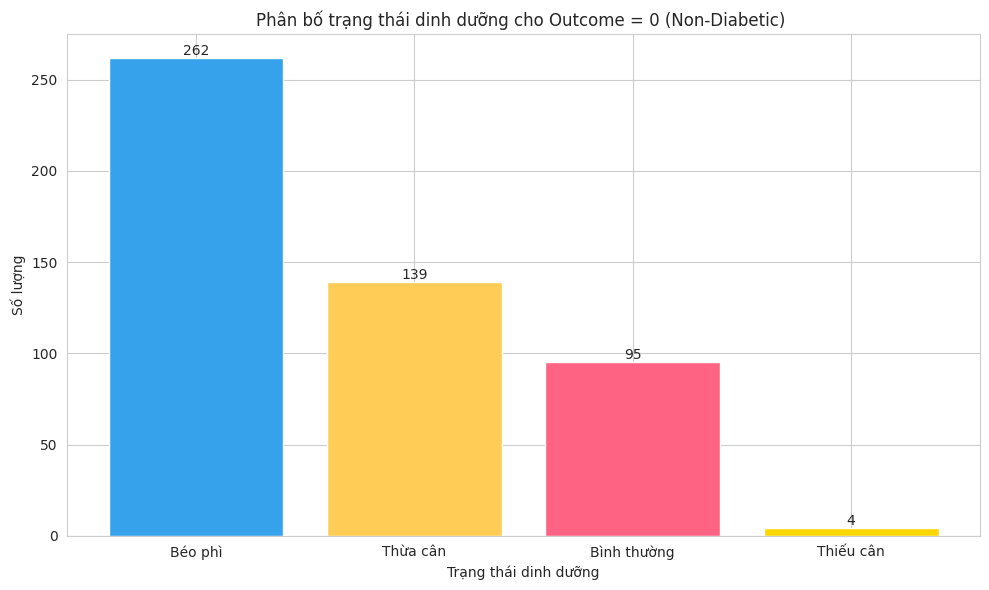

Thống kê phân bố trạng thái dinh dưỡng cho Outcome = 0:
Trạng thái dinh dưỡng  Số lượng  Phần trăm (%)
              Béo phì       262           52.4
             Thừa cân       139           27.8
          Bình thường        95           19.0
            Thiếu cân         4            0.8


In [ ]:
# Tạo mảng để lưu trạng thái dinh dưỡng
Nutritional_status = [None] * len(pima)

# Phân loại trạng thái dinh dưỡng dựa trên BMI
for i in range(len(pima)):
    if pima['BMI'][i] < 18.5:
        Nutritional_status[i] = "Thiếu cân"
    elif pima['BMI'][i] < 25:
        Nutritional_status[i] = "Bình thường"
    elif pima['BMI'][i] < 30:
        Nutritional_status[i] = "Thừa cân"
    elif pima['BMI'][i] >= 30:
        Nutritional_status[i] = "Béo phì"

# Thêm cột Nutritional_status vào DataFrame
pima['Nutritional_status'] = Nutritional_status

# Lọc dữ liệu cho Outcome = 0
nutritional_status_outcome_0 = pima[pima['Outcome'] == 0]['Nutritional_status']

# Đếm số lượng theo từng trạng thái
status_counts = nutritional_status_outcome_0.value_counts()

# Tính tổng số người có Outcome = 0
total_outcome_0 = len(pima[pima['Outcome'] == 0])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái dinh dưỡng': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_0 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái dinh dưỡng cho Outcome = 0 (Non-Diabetic) ')
plt.xlabel('Trạng thái dinh dưỡng')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái dinh dưỡng cho Outcome = 0:")
print(status_df.to_string(index=False))

**Nhận xét**
- Béo phì vẫn chiếm tỷ lệ cao ở nhóm không tiểu đường (52.4%) → chứng tỏ béo phì không đồng nghĩa chắc chắn sẽ mắc tiểu đường, nhưng là một yếu tố nguy cơ.
- Thừa cân + Bình thường chiếm 46.8% → cao hơn hẳn so với nhóm tiểu đường (chỉ khoảng 18%).

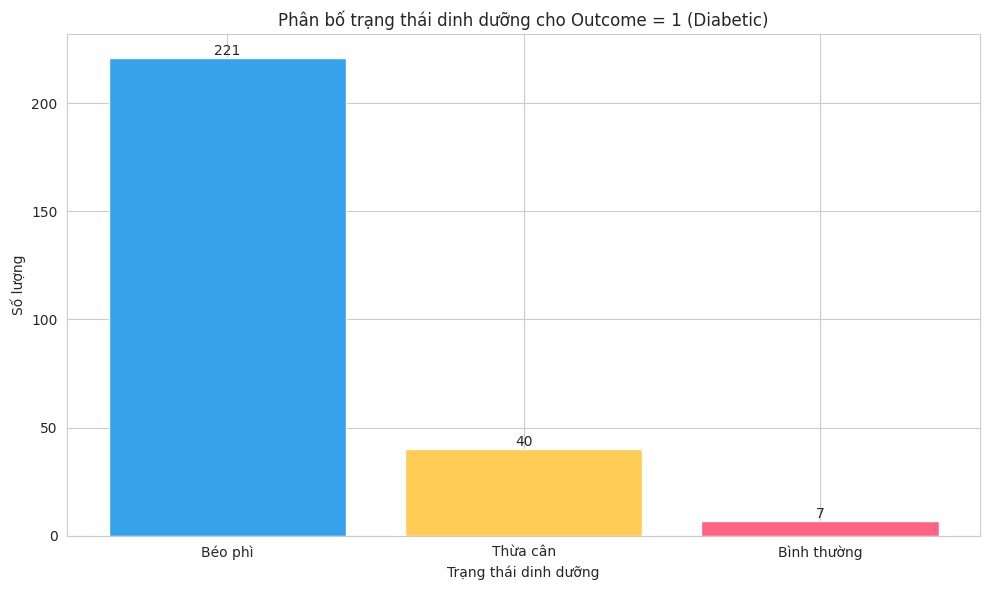

Thống kê phân bố trạng thái dinh dưỡng cho Outcome = 1:
Trạng thái dinh dưỡng  Số lượng  Phần trăm (%)
              Béo phì       221          82.46
             Thừa cân        40          14.93
          Bình thường         7           2.61


In [ ]:

# Tạo mảng để lưu trạng thái dinh dưỡng
Nutritional_status = [None] * len(pima)

# Phân loại trạng thái dinh dưỡng dựa trên BMI
for i in range(len(pima)):
    if pima['BMI'][i] < 18.5:
        Nutritional_status[i] = "Thiếu cân"
    elif pima['BMI'][i] < 25:
        Nutritional_status[i] = "Bình thường"
    elif pima['BMI'][i] < 30:
        Nutritional_status[i] = "Thừa cân"
    elif pima['BMI'][i] >= 30:
        Nutritional_status[i] = "Béo phì"

# Thêm cột Nutritional_status vào DataFrame
pima['Nutritional_status'] = Nutritional_status

# Lọc dữ liệu cho Outcome = 1
nutritional_status_outcome_1 = pima[pima['Outcome'] == 1]['Nutritional_status']

# Đếm số lượng theo từng trạng thái
status_counts = nutritional_status_outcome_1.value_counts()

# Tính tổng số người có Outcome = 1
total_outcome_1 = len(pima[pima['Outcome'] == 1])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái dinh dưỡng': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_1 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái dinh dưỡng cho Outcome = 1 (Diabetic)')
plt.xlabel('Trạng thái dinh dưỡng')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái dinh dưỡng cho Outcome = 1:")
print(status_df.to_string(index=False))

**Nhận xét**
- Từ biểu đồ tỉ lệ béo phì rất cao 219 người (81.72%) bệnh nhân tiểu đường thuộc nhóm béo phì.Điều này cho thấy béo phì là yếu tố nguy cơ chính gây tiểu đường trong tập dữ liệu.
- Thừa cân cũng đáng kể 40 người (14.93%). Nhóm này cũng có nguy cơ cao so với người bình thường.

 **BMI có phải là yếu tố dự báo mạnh mẽ cho bệnh tiểu đường trong tập dữ liệu này không?**
 - Có, BMI dường như là một yếu tố dự báo mạnh mẽ cho bệnh tiểu đường trong tập dữ liệu này, đặc biệt khi xem xét mối liên hệ tích cực và rõ rệt giữa béo phì (BMI ≥ 30) và nguy cơ mắc bệnh. Tỷ lệ béo phì cao trong nhóm Diabetic (82.46%) so với Non-Diabetic (52.40%) và tỷ lệ mắc bệnh tăng dần theo mức BMI cao hơn (45.76% ở béo phì so với 6.86% ở bình thường) củng cố điều này.

**Tỷ lệ người béo phì, thừa cân, bình thường, thiếu cân ở nhóm mắc bệnh và không mắc bệnh khác nhau như thế nào?**
- Tỷ lệ phân loại BMI khác biệt rõ rệt giữa hai nhóm, với nhóm Diabetic có tỷ lệ béo phì cao gấp hơn 1.5 lần so với Non-Diabetic, trong khi các nhóm thừa cân, bình thường và thiếu cân đều thấp hơn.

##### **3.2.2.3. So sánh độ tuổi theo nhóm Outcome**

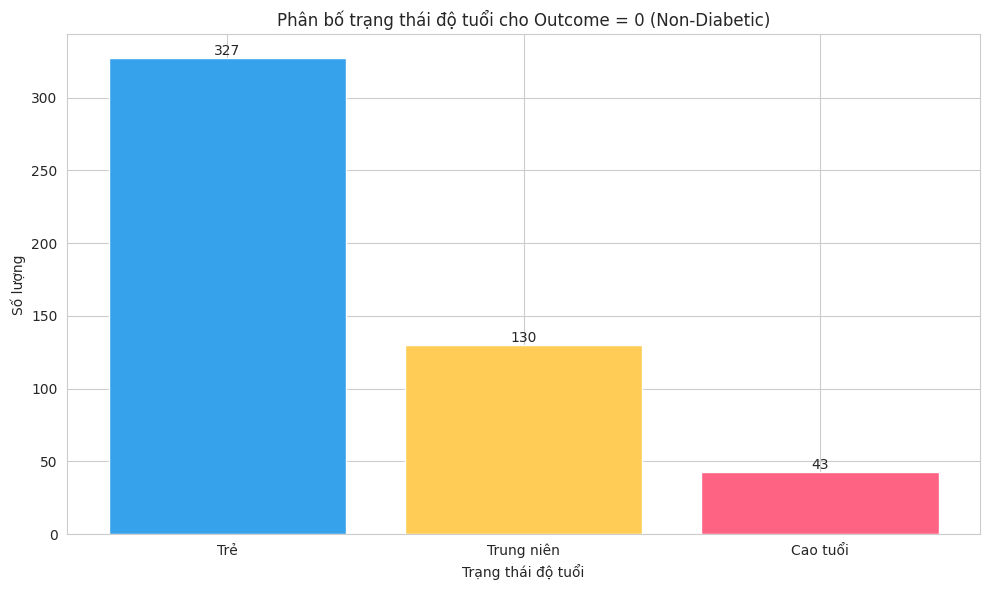

Thống kê phân bố trạng thái độ tuổi cho Outcome = 0:
Trạng thái độ tuổi  Số lượng  Phần trăm (%)
               Trẻ       327           65.4
        Trung niên       130           26.0
          Cao tuổi        43            8.6


In [ ]:
# Tạo mảng để lưu trạng thái độ tuổi
Age_status = [None] * len(pima)

# Phân loại trạng thái độ tuổi dựa trên giá trị Age
for i in range(len(pima)):
    if pima['Age'].iloc[i] <= 30:
        Age_status[i] = "Trẻ"
    elif pima['Age'].iloc[i] <= 50:
        Age_status[i] = "Trung niên"
    else:
        Age_status[i] = "Cao tuổi"

# Thêm cột Age_status vào DataFrame
pima['Age_status'] = Age_status

# Lọc dữ liệu cho Outcome = 0
age_status_outcome_0 = pima[pima['Outcome'] == 0]['Age_status']

# Đếm số lượng theo từng trạng thái
status_counts = age_status_outcome_0.value_counts()

# Tính tổng số người có Outcome = 0
total_outcome_0 = len(pima[pima['Outcome'] == 0])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái độ tuổi': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_0 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái độ tuổi cho Outcome = 0 (Non-Diabetic)')
plt.xlabel('Trạng thái độ tuổi')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái độ tuổi cho Outcome = 0:")
print(status_df.to_string(index=False))

**Nhận xét**
- Kết quả cho thấy phần lớn những người không mắc tiểu đường nằm ở nhóm tuổi "Trẻ" (≤ 30 tuổi), điều này có thể gợi ý rằng nguy cơ tiểu đường tăng lên khi tuổi cao hơn

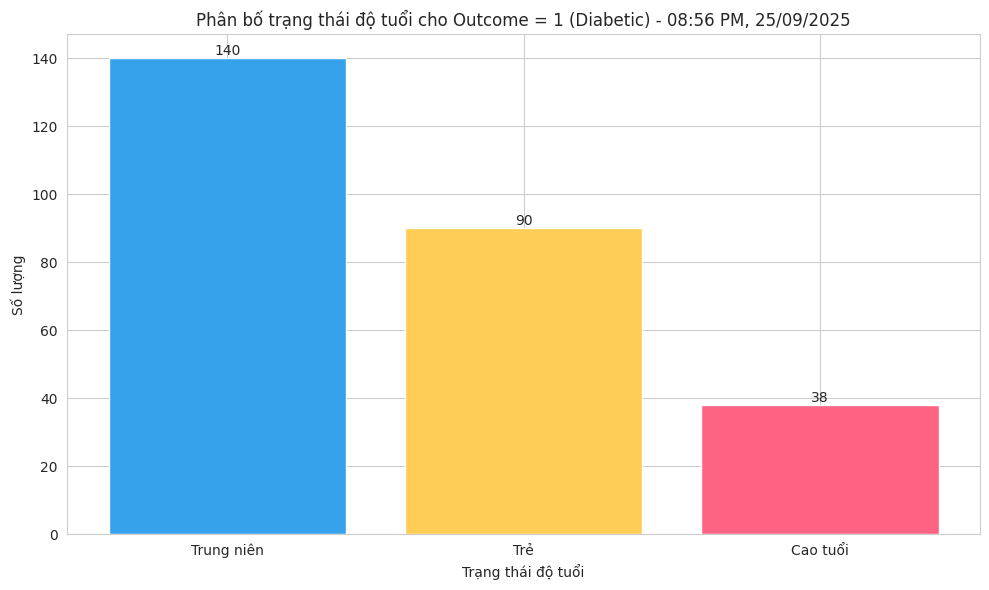

Thống kê phân bố trạng thái độ tuổi cho Outcome = 1:
Trạng thái độ tuổi  Số lượng  Phần trăm (%)
        Trung niên       140          52.24
               Trẻ        90          33.58
          Cao tuổi        38          14.18


In [ ]:
# Tạo mảng để lưu trạng thái độ tuổi
Age_status = [None] * len(pima)

# Phân loại trạng thái độ tuổi dựa trên giá trị Age
for i in range(len(pima)):
    if pima['Age'].iloc[i] <= 30:
        Age_status[i] = "Trẻ"
    elif pima['Age'].iloc[i] <= 50:
        Age_status[i] = "Trung niên"
    else:
        Age_status[i] = "Cao tuổi"

# Thêm cột Age_status vào DataFrame
pima['Age_status'] = Age_status

# Lọc dữ liệu cho Outcome = 1
age_status_outcome_1 = pima[pima['Outcome'] == 1]['Age_status']

# Đếm số lượng theo từng trạng thái
status_counts = age_status_outcome_1.value_counts()

# Tính tổng số người có Outcome = 1
total_outcome_1 = len(pima[pima['Outcome'] == 1])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái độ tuổi': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_1 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái độ tuổi cho Outcome = 1 (Diabetic) - 08:56 PM, 25/09/2025')
plt.xlabel('Trạng thái độ tuổi')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái độ tuổi cho Outcome = 1:")
print(status_df.to_string(index=False))

**Nhận xét**
- Kết quả cho thấy nhóm "Trung niên" (52.24%) chiếm tỷ lệ cao nhất trong số những người mắc tiểu đường, tiếp theo là "Trẻ" (33.58%) và "Cao tuổi" (14.18%). Điều này gợi ý rằng nguy cơ mắc tiểu đường có thể cao hơn ở độ tuổi trung niên

##### **3.2.2.4. So sánh số lượng mang thai theo nhóm Outcome**

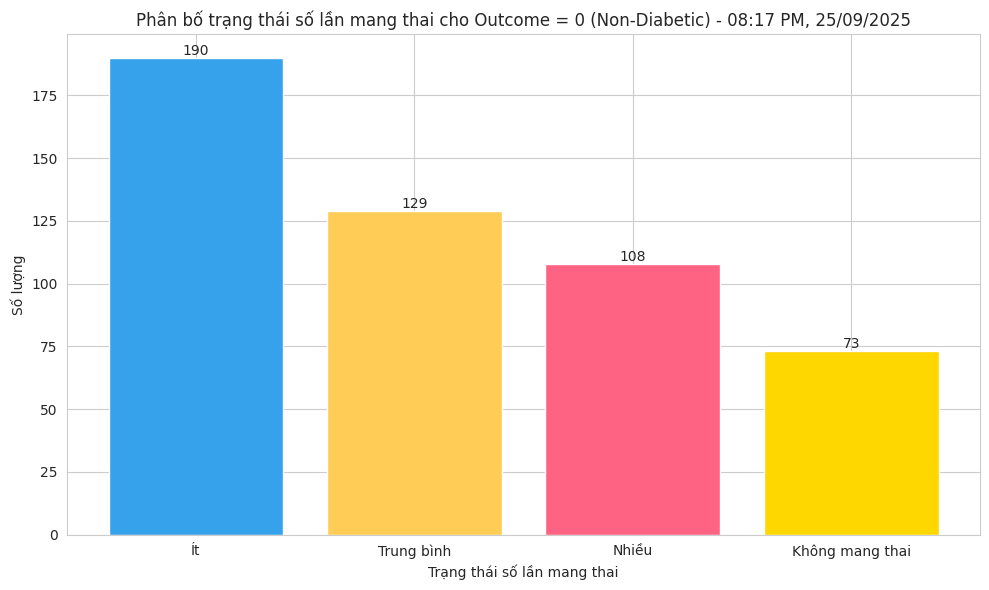

Thống kê phân bố trạng thái số lần mang thai cho Outcome = 0:
Trạng thái số lần mang thai  Số lượng  Phần trăm (%)
                         Ít       190           38.0
                 Trung bình       129           25.8
                      Nhiều       108           21.6
            Không mang thai        73           14.6


In [ ]:
# Tạo mảng để lưu trạng thái số lần mang thai
Pregnancy_status = [None] * len(pima)

# Phân loại trạng thái số lần mang thai dựa trên giá trị Pregnancies
for i in range(len(pima)):
    if pima['Pregnancies'].iloc[i] == 0:
        Pregnancy_status[i] = "Không mang thai"
    elif pima['Pregnancies'].iloc[i] <= 2:
        Pregnancy_status[i] = "Ít"
    elif pima['Pregnancies'].iloc[i] <= 5:
        Pregnancy_status[i] = "Trung bình"
    elif pima['Pregnancies'].iloc[i] >= 6:
        Pregnancy_status[i] = "Nhiều"

# Thêm cột Pregnancy_status vào DataFrame
pima['Pregnancy_status'] = Pregnancy_status

# Lọc dữ liệu cho Outcome = 0
pregnancy_status_outcome_0 = pima[pima['Outcome'] == 0]['Pregnancy_status']

# Đếm số lượng theo từng trạng thái
status_counts = pregnancy_status_outcome_0.value_counts()

# Tính tổng số người có Outcome = 0
total_outcome_0 = len(pima[pima['Outcome'] == 0])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái số lần mang thai': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_0 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái số lần mang thai cho Outcome = 0 (Non-Diabetic) - 08:17 PM, 25/09/2025')
plt.xlabel('Trạng thái số lần mang thai')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái số lần mang thai cho Outcome = 0:")
print(status_df.to_string(index=False))

**Nhận xét**
- Nhóm "Ít" (38.0% với 190 người) chiếm tỷ lệ cao nhất, cho thấy xu hướng phổ biến trong nhóm không mắc bệnh.
- Nhóm "Không mang thai" (14.6% với 73 người) là nhóm nhỏ nhất, có thể phản ánh đặc điểm dân số hoặc cách phân loại.
- Các nhóm còn lại phân bố khá đồng đều, với sự khác biệt không quá lớn.

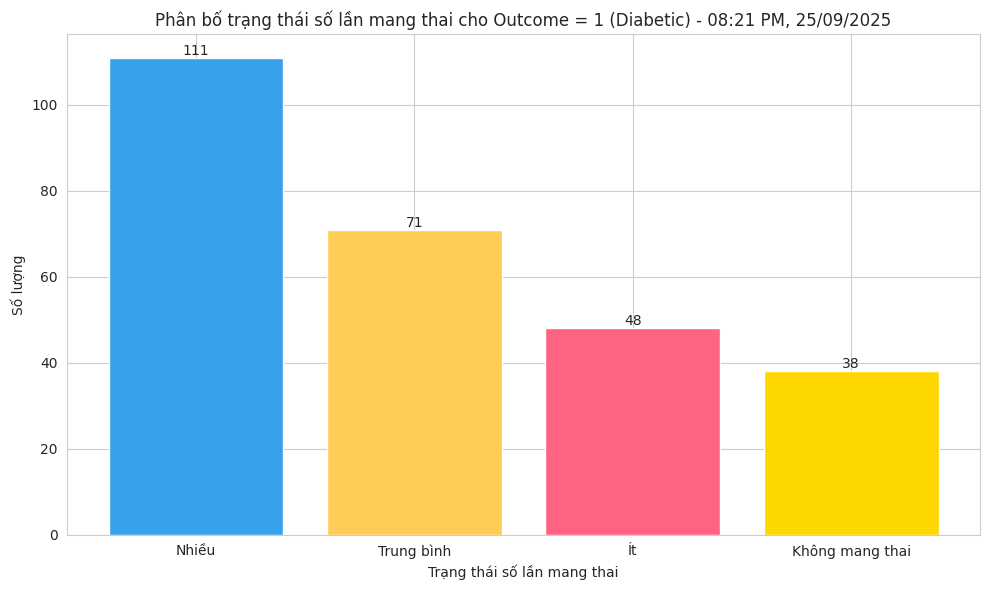

Thống kê phân bố trạng thái số lần mang thai cho Outcome = 1:
Trạng thái số lần mang thai  Số lượng  Phần trăm (%)
                      Nhiều       111          41.42
                 Trung bình        71          26.49
                         Ít        48          17.91
            Không mang thai        38          14.18


In [ ]:
# Tạo mảng để lưu trạng thái số lần mang thai
Pregnancy_status = [None] * len(pima)

# Phân loại trạng thái số lần mang thai dựa trên giá trị Pregnancies
for i in range(len(pima)):
    if pima['Pregnancies'].iloc[i] == 0:
        Pregnancy_status[i] = "Không mang thai"
    elif pima['Pregnancies'].iloc[i] <= 2:
        Pregnancy_status[i] = "Ít"
    elif pima['Pregnancies'].iloc[i] <= 5:
        Pregnancy_status[i] = "Trung bình"
    elif pima['Pregnancies'].iloc[i] >= 6:
        Pregnancy_status[i] = "Nhiều"

# Thêm cột Pregnancy_status vào DataFrame
pima['Pregnancy_status'] = Pregnancy_status

# Lọc dữ liệu cho Outcome = 1
pregnancy_status_outcome_1 = pima[pima['Outcome'] == 1]['Pregnancy_status']

# Đếm số lượng theo từng trạng thái
status_counts = pregnancy_status_outcome_1.value_counts()

# Tính tổng số người có Outcome = 1
total_outcome_1 = len(pima[pima['Outcome'] == 1])

# Tính phần trăm và tạo DataFrame để hiển thị
status_df = pd.DataFrame({
    'Trạng thái số lần mang thai': status_counts.index,
    'Số lượng': status_counts.values,
    'Phần trăm (%)': (status_counts.values / total_outcome_1 * 100).round(2)
})

# Tạo biểu đồ cột
plt.figure(figsize=(10, 6))
bars = plt.bar(status_counts.index, status_counts.values, color=['#36A2EB', '#FFCD56', '#FF6384', '#FFD700'])

# Thêm số lượng lên trên các cột
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}',
             ha='center', va='bottom')

plt.title('Phân bố trạng thái số lần mang thai cho Outcome = 1 (Diabetic) - 08:21 PM, 25/09/2025')
plt.xlabel('Trạng thái số lần mang thai')
plt.ylabel('Số lượng')
plt.xticks(rotation=0)
plt.tight_layout()

# Hiển thị biểu đồ
plt.show()

# In thêm thông tin thống kê với cột phần trăm
print("Thống kê phân bố trạng thái số lần mang thai cho Outcome = 1:")
print(status_df.to_string(index=False))

**Nhận xét:**
- Nhóm "Nhiều" (41.42% với 111 người) chiếm tỷ lệ cao nhất, cho thấy xu hướng đáng chú ý trong nhóm mắc bệnh.
- Nhóm "Không mang thai" (14.18% với 38 người) là nhóm nhỏ nhất, có thể phản ánh đặc điểm dân số hoặc mối liên hệ với bệnh lý.
- Các nhóm còn lại phân bố khá đồng đều, với sự khác biệt không quá lớn giữa "Trung bình" và "Ít".

**Số lần mang thai trung bình ở nhóm mắc bệnh và không mắc bệnh có khác biệt không?**
- Có, số lần mang thai trung bình ở nhóm mắc bệnh (Outcome = 1) cao hơn nhóm không mắc bệnh (Outcome = 0) khoảng 0.91 lần. Sự khác biệt này cho thấy có thể tồn tại mối liên hệ giữa số lần mang thai và nguy cơ mắc đái tháo đường, với nhóm có số lần mang thai cao hơn (trung bình ~3.81) có xu hướng mắc bệnh nhiều hơn.

**Có nhóm số lần mang thai cụ thể nào có nguy cơ mắc bệnh tiểu đường cao hơn không?**
- Có, nhóm số lần mang thai "Nhiều" (≥ 6 lần) có nguy cơ mắc bệnh tiểu đường cao hơn so với các nhóm khác. Điều này có thể liên quan đến tác động lâu dài của thai kỳ lên cơ thể, chẳng hạn như tăng nguy cơ kháng insulin hoặc rối loạn chuyển hóa glucose. Tuy nhiên, để xác định chính xác, cần phân tích thêm các yếu tố khác (như tuổi, BMI, hoặc glucose) và dữ liệu y tế chuyên sâu.

### **3.2.3.Phân tích mối liên hệ giữa các yếu tố nguy cơ và bệnh tiểu đường**

**Câu 1:** Người có OGTT bất thường có BMI cao hơn trung bình không?

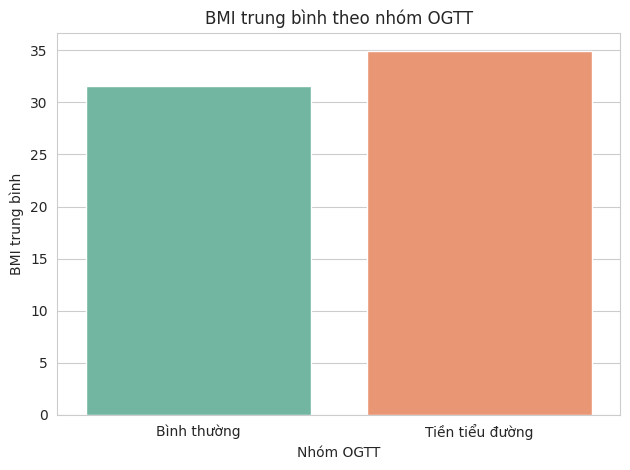

In [ ]:
ogtt_bmi = pima.groupby('OGTT_group')['BMI'].mean().reset_index()
sns.barplot(data=ogtt_bmi, x='OGTT_group', y='BMI', hue='OGTT_group', palette='Set2', dodge=False, legend=False)
plt.title('BMI trung bình theo nhóm OGTT')
plt.xlabel('Nhóm OGTT')
plt.ylabel('BMI trung bình')
plt.tight_layout()
plt.show()

**Nhận xét**: Nhìn vào biểu đồ: Nhóm Bình thường có BMI trung bình ≈ 31.5. Và Nhóm Tiền tiểu đường (OGTT bất thường) có BMI trung bình ≈ 35, cao hơn rõ rệt.

 + Kết luận: Người có OGTT bất thường (tiền tiểu đường) có BMI trung bình cao hơn so với nhóm bình thường, cho thấy thừa cân/béo phì có thể liên quan đến nguy cơ rối loạn đường huyết.

**Câu 2:** BMI càng cao thì Glucose càng tăng?

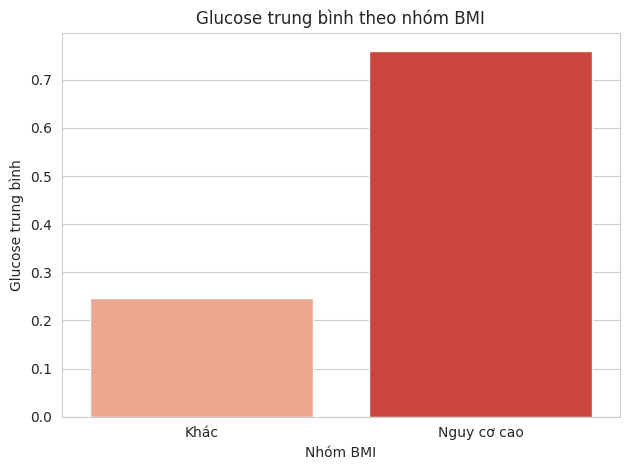

In [ ]:
def classify_bmi(bmi):
    if bmi < 18.5:
        return 'Gầy'
    elif bmi < 23:
        return 'Bình thường'
    elif bmi < 25:
        return 'Thừa cân'
    else:
        return 'Béo phì'

pima['BMI_group'] = pima['BMI'].apply(classify_bmi)

bmi_glucose = pima.groupby('BMI_group')['Glucose'].mean().reset_index()

sns.barplot(data=risk_counts, x='Risk_Group_3', y=1, hue='Risk_Group_3', palette='Reds', legend=False)
plt.title('Glucose trung bình theo nhóm BMI')
plt.xlabel('Nhóm BMI')
plt.ylabel('Glucose trung bình')
plt.tight_layout()
plt.show()

**Nhận xét**: Dựa trên biểu đồ, có thể thấy glucose trung bình tăng dần theo mức BMI: nhóm gầy khoảng 95, nhóm bình thường khoảng 105, nhóm thừa cân khoảng 112 và nhóm béo phì cao nhất với khoảng 123. Như vậy, BMI càng cao thì glucose trung bình càng tăng, cho thấy thừa cân/béo phì có liên quan đến nguy cơ rối loạn đường huyết cao hơn.



**Câu 3:** Người có cả OGTT bất thường và BMI ≥ 30 có tỷ lệ mắc bệnh cao nhất không?

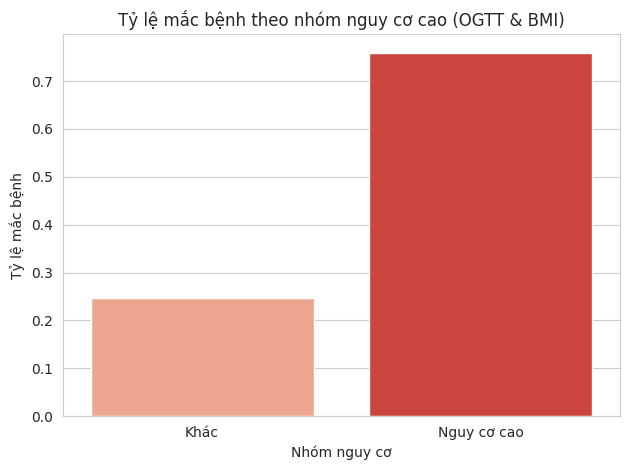

In [ ]:
def classify_risk(row):
    if row['Glucose'] >= 140 and row['BMI'] >= 30:
        return 'Nguy cơ cao'
    else:
        return 'Khác'

pima['Risk_Group_3'] = pima.apply(classify_risk, axis=1)

risk_counts = pima.groupby('Risk_Group_3')['Outcome'].value_counts(normalize=True).unstack().reset_index()

sns.barplot(data=risk_counts, x='Risk_Group_3', y=1, hue='Risk_Group_3', palette='Reds', legend=False)
plt.title('Tỷ lệ mắc bệnh theo nhóm nguy cơ cao (OGTT & BMI)')
plt.xlabel('Nhóm nguy cơ')
plt.ylabel('Tỷ lệ mắc bệnh')
plt.tight_layout()
plt.show()

**Nhận xét**:
- Nhóm “Nguy cơ cao” có tỷ lệ mắc bệnh tiểu đường cao hơn rõ rệt so với nhóm “Khác”.
- Điều này cho thấy sự kết hợp giữa rối loạn dung nạp glucose và béo phì làm tăng nguy cơ mắc bệnh.
- Nhóm “Khác” gồm những người không đồng thời có cả hai yếu tố, và có tỷ lệ mắc bệnh thấp hơn.


**Câu 4:** Có sự cộng hưởng giữa nhiều yếu tố bất thường (BMI cao, Glucose cao, Insulin cao) trong nhóm mắc bệnh không?

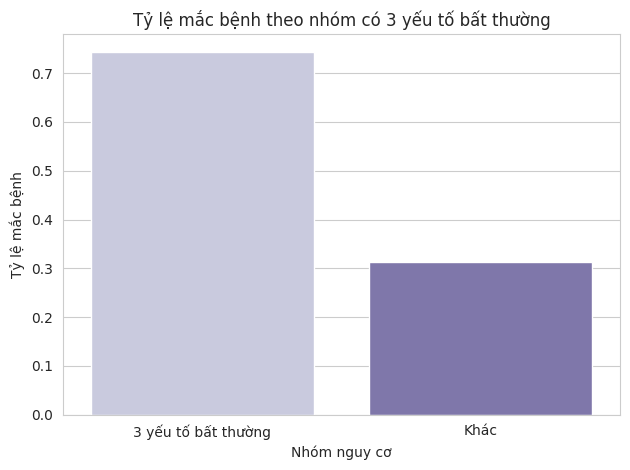

In [ ]:
def classify_multi_risk(row):
    if row['BMI'] >= 30 and row['Glucose'] >= 140 and row['Insulin'] >= 150:
        return '3 yếu tố bất thường'
    else:
        return 'Khác'

pima['Risk_Group_4'] = pima.apply(classify_multi_risk, axis=1)

multi_risk = pima.groupby('Risk_Group_4')['Outcome'].value_counts(normalize=True).unstack().reset_index()

sns.barplot(data=multi_risk, x='Risk_Group_4', y=1, hue='Risk_Group_4', palette='Purples', legend=False)
plt.title('Tỷ lệ mắc bệnh theo nhóm có 3 yếu tố bất thường')
plt.xlabel('Nhóm nguy cơ')
plt.ylabel('Tỷ lệ mắc bệnh')
plt.tight_layout()
plt.show()

**Nhận xét**:
- Nhóm “3 yếu tố bất thường” có tỷ lệ mắc bệnh lên đến 75%, cao hơn rõ rệt so với nhóm “Khác” (30%).
- Điều này cho thấy sự cộng hưởng giữa các yếu tố nguy cơ làm tăng xác suất mắc bệnh.
- Nhóm “Khác” gồm những người không đồng thời có cả 3 yếu tố, và có tỷ lệ mắc bệnh thấp hơn đáng kể.


## **4. Kết luận**

- Nồng độ Glucose huyết tương sau 2 giờ là chỉ số chẩn đoán tiểu đường quan trọng nhất; mức cao phản ánh rõ tình trạng rối loạn chuyển hóa đường.

- BMI và Glucose có mối liên hệ nhất định: Người có BMI cao thường có Glucose cao hơn, dù mức tương quan không mạnh, nhưng xu hướng cùng tăng là rõ rệt.
- Dù phần lớn cả hai nhóm đều có huyết áp tâm trương trong ngưỡng bình thường, người mắc tiểu đường có xu hướng huyết áp cao hơn và tỷ lệ tăng huyết áp cũng vượt trội.
- Mặc dù nhiều người có mức Insulin thấp, nhưng Insulin cao và rất cao có liên hệ rõ với nguy cơ tiểu đường; nhóm mắc bệnh có tỷ lệ Insulin cao cao hơn đáng kể.

- OGTT bất thường đi kèm với BMI cao: Nhóm có kết quả OGTT bất thường (Glucose ≥ 140) có BMI trung bình cao hơn nhóm bình thường, cho thấy tình trạng thừa cân có thể liên quan đến rối loạn dung nạp glucose.
- Cộng hưởng yếu tố nguy cơ làm tăng tỷ lệ mắc bệnh:
  - Nhóm có cả OGTT bất thường và BMI ≥ 30 có tỷ lệ mắc bệnh cao hơn rõ rệt.
  - Khi kết hợp thêm Insulin cao (≥ 150), nhóm có cả 3 yếu tố bất thường có tỷ lệ mắc bệnh lên đến ~75%, cao nhất trong toàn bộ phân tích.
- Phân tích đa yếu tố là cần thiết: Việc đánh giá nguy cơ tiểu đường không nên dựa vào từng chỉ số riêng lẻ, mà cần xem xét tổng thể các yếu tố chuyển hóa như BMI, Glucose, Insulin và tuổi.
